Total Rows: 279429
Date Range: 1970-01-01 to 1970-01-01

Training on: 223543 rows
Testing on: 55886 rows

Training MP Production XGBoost Model...

--- MP Production Results (Chronological Test Set) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     53077
           1       0.84      0.62      0.71      2809

    accuracy                           0.97     55886
   macro avg       0.91      0.81      0.85     55886
weighted avg       0.97      0.97      0.97     55886



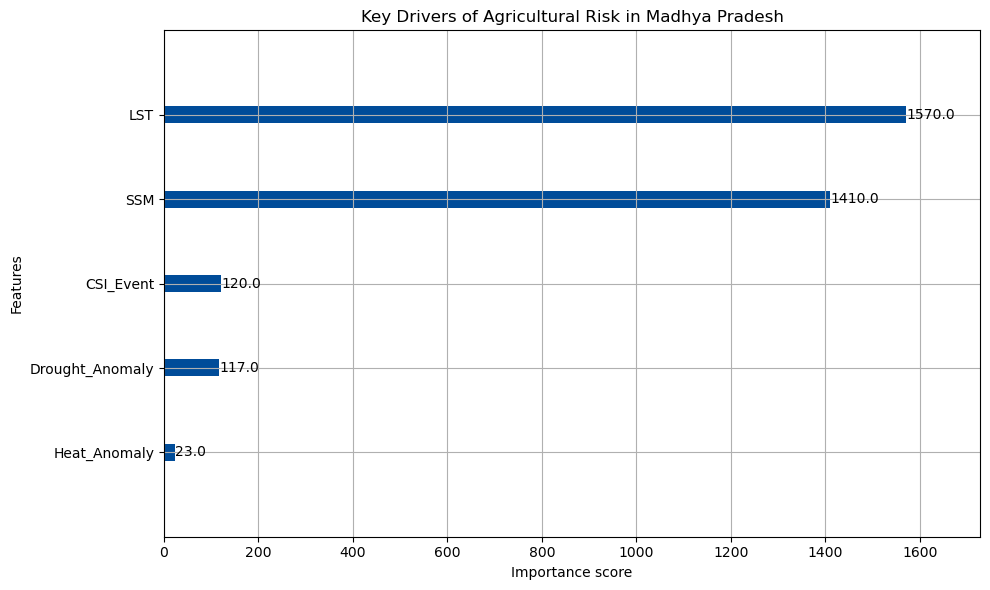

✅ SUCCESS: MP Production Model saved to src/mp_production_model_v1.json
🚀 Final Step: Training 'Master Model' on 100% of MP Data...
✅ SUCCESS: The Final Master Model is now trained on the full 15-year range and saved.


In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# 1. LOAD DATA
df = pd.read_csv("../data/processed/mp_production_master.csv")
df['Date'] = pd.to_datetime(df['Date'])

# --- DATA AUDIT (Let's see what we have) ---
print(f"Total Rows: {len(df)}")
print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")

# 2. ROBUST SPLIT (80% Train, 20% Test)
# We sort by date first to ensure we are testing on the "Future"
df = df.sort_values('Date')

features = ['LST', 'SSM', 'Heat_Anomaly', 'Drought_Anomaly', 
            'Is_Kharif_Critical', 'Is_Rabi_Critical', 'CSI_Event']
target = 'Target_Failure'

# We use shuffle=False to keep the chronological order (Testing on the last 20% of time)
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df[target], test_size=0.2, shuffle=False
)

print(f"\nTraining on: {len(X_train)} rows")
print(f"Testing on: {len(X_test)} rows")

if len(X_test) == 0:
    print("❌ ERROR: Test set is still empty. Check your CSV loading logic.")
else:
    # 3. TRAIN MP PRODUCTION MODEL
    print("\nTraining MP Production XGBoost Model...")
    model = xgb.XGBClassifier(
        n_estimators=150, 
        max_depth=5, 
        scale_pos_weight=4, 
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X_train, y_train)

    # 4. EVALUATE
    preds = model.predict(X_test)
    print("\n--- MP Production Results (Chronological Test Set) ---")
    
    # We check if we actually have failures in the test set to report on
    if len(np.unique(y_test)) > 1:
        print(classification_report(y_test, preds))
    else:
        print("Note: Test set only contains one class (No failures detected in this period).")

    # 5. FEATURE IMPORTANCE
    plt.figure(figsize=(10, 6))
    xgb.plot_importance(model, color='#004C99', ax=plt.gca())
    plt.title("Key Drivers of Agricultural Risk in Madhya Pradesh")
    plt.tight_layout()
    plt.show()

    # 6. SAVE THE PRODUCTION MODEL
    os.makedirs("../src", exist_ok=True)
    model.save_model("../src/mp_production_model_v1.json")
    print("✅ SUCCESS: MP Production Model saved to src/mp_production_model_v1.json") 
    
    
    print("🚀 Final Step: Training 'Master Model' on 100% of MP Data...")

# We use the full X and y (no split)
X_full = df[features]
y_full = df[target]

# Initialize the model with the same winning parameters
final_production_model = xgb.XGBClassifier(
    n_estimators=150, 
    max_depth=5, 
    scale_pos_weight=4, 
    learning_rate=0.05,
    random_state=42
)

# Train on 100% of the 15-year history
final_production_model.fit(X_full, y_full)

# Overwrite the previous saved model with this "All-Knowing" version
final_production_model.save_model("../src/mp_production_model_v1.json")

print("✅ SUCCESS: The Final Master Model is now trained on the full 15-year range and saved.") 